# Signal Analysis with Python

Practical signal-processing recipes using **NumPy** and **SciPy**.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
from scipy.fft import fft, fftshift, fftfreq
from scipy.stats import gaussian_kde
import ipywidgets as widgets
from IPython.display import display, clear_output
%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

---
## Generate Simple Signals

Four common test signals built from scratch:

| Signal | Expression |
|--------|------------|
| Sine wave | $x(t) = A\sin(2\pi f_0 t + \phi)$ |
| Square wave | $x(t) = A\,\mathrm{sign}\!\left(\sin(2\pi f_0 t)\right)$ |
| Linear chirp | $x(t) = A\cos\!\left(2\pi\left(f_0 t + \frac{\mu}{2}t^2\right)\right)$ |
| Gaussian pulse | $x(t) = A\,e^{-t^2/(2\sigma^2)}\cos(2\pi f_0 t)$ |

In [ ]:
# Interactive signal generation — control parameters per signal type
out_sig = widgets.Output()

sig_type = widgets.Dropdown(
    options=['Sine', 'Square', 'Chirp', 'Gaussian pulse'],
    value='Sine', description='Signal:',
    style={'description_width': 'initial'},
)
freq_slider = widgets.FloatSlider(
    value=50, min=1, max=400, step=1,
    description='f\u2080 (Hz):', style={'description_width': 'initial'},
    layout=widgets.Layout(width='45%'),
)
amp_slider = widgets.FloatSlider(
    value=1.0, min=0.1, max=3.0, step=0.1,
    description='Amplitude:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='45%'),
)
phase_slider = widgets.FloatSlider(
    value=0, min=-180, max=180, step=5,
    description='Phase (\u00b0):', style={'description_width': 'initial'},
    layout=widgets.Layout(width='45%'),
)
f1_slider = widgets.FloatSlider(
    value=200, min=10, max=450, step=5,
    description='f\u2081 (Hz):', style={'description_width': 'initial'},
    layout=widgets.Layout(width='45%'),
)
sigma_slider = widgets.FloatSlider(
    value=15, min=2, max=40, step=1,
    description='\u03c3 (ms):', style={'description_width': 'initial'},
    layout=widgets.Layout(width='45%'),
)
fs_sig_slider = widgets.IntSlider(
    value=1000, min=200, max=5000, step=100,
    description='fs (Hz):', style={'description_width': 'initial'},
    layout=widgets.Layout(width='45%'),
)
dur_slider = widgets.FloatSlider(
    value=100, min=10, max=500, step=10,
    description='Duration (ms):', style={'description_width': 'initial'},
    layout=widgets.Layout(width='45%'),
)

def update_signal(*args):
    fs_s = fs_sig_slider.value
    T_s = dur_slider.value / 1e3
    t_s = np.arange(0, T_s, 1/fs_s)
    if len(t_s) == 0:
        return
    f0_s = freq_slider.value
    A_s = amp_slider.value
    phi_s = np.radians(phase_slider.value)
    kind = sig_type.value

    if kind == 'Sine':
        x_s = A_s * np.sin(2 * np.pi * f0_s * t_s + phi_s)
        title = f'Sine  f0={f0_s:.0f} Hz, A={A_s:.1f}, phase={phase_slider.value:.0f} deg'
    elif kind == 'Square':
        x_s = A_s * sig.square(2 * np.pi * f0_s * t_s + phi_s)
        title = f'Square  f0={f0_s:.0f} Hz, A={A_s:.1f}, phase={phase_slider.value:.0f} deg'
    elif kind == 'Chirp':
        f1_s = f1_slider.value
        x_s = A_s * sig.chirp(t_s, f0=f0_s, f1=f1_s, t1=T_s, method='linear', phi=np.degrees(phi_s))
        title = f'Chirp  {f0_s:.0f} -> {f1_s:.0f} Hz, A={A_s:.1f}'
    else:
        sig_g = sigma_slider.value / 1e3
        tc = t_s - T_s / 2
        x_s = A_s * np.exp(-tc**2 / (2 * sig_g**2)) * np.cos(2 * np.pi * f0_s * tc + phi_s)
        title = f'Gaussian pulse  f0={f0_s:.0f} Hz, sigma={sigma_slider.value:.0f} ms'

    N_s = len(t_s)
    Nfft_s = max(N_s, 2048)
    f_ax_s = fftshift(fftfreq(Nfft_s, 1/fs_s))
    X_s = fftshift(fft(x_s, n=Nfft_s)) / N_s

    with out_sig:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
        axes[0].plot(t_s * 1e3, x_s, '#4C72B0', lw=1.5)
        axes[0].set_title(title)
        axes[0].set_xlabel('Time (ms)')
        axes[0].set_ylabel('Amplitude')

        axes[1].plot(f_ax_s, np.abs(X_s), '#C44E52', lw=1.5)
        axes[1].set_xlim(-fs_s/2, fs_s/2)
        axes[1].set_title(f'Spectrum  (fs = {fs_s} Hz, df = {fs_s/N_s:.1f} Hz)')
        axes[1].set_xlabel('Frequency (Hz)')
        axes[1].set_ylabel('|X(f)| / N')

        fig.suptitle('Interactive Signal Generation', fontweight='bold', fontsize=13)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

for w in [sig_type, freq_slider, amp_slider, phase_slider, f1_slider, sigma_slider, fs_sig_slider, dur_slider]:
    w.observe(update_signal, names='value')

display(widgets.VBox([
    widgets.HBox([sig_type, fs_sig_slider, dur_slider]),
    widgets.HBox([freq_slider, amp_slider]),
    widgets.HBox([phase_slider, f1_slider, sigma_slider]),
    out_sig,
]))
update_signal()

---
## FFT, FFTshift, and Bin Spacing

$$X[k] = \sum_{n=0}^{N-1} x[n]\,e^{-j2\pi kn/N}, \qquad k = 0,\dots,N-1$$

- `fft` returns bins $[0, f_s)$ — positive first, then negative (wrapped)
- `fftshift` reorders to $[-f_s/2,\, +f_s/2)$ — centered around DC

### How to reason about bin spacing

The **frequency resolution** (bin spacing) of the FFT is:

$$\Delta f = \frac{f_s}{N} = \frac{1}{T}$$

where $T = N / f_s$ is the observation window duration.

| You want finer Δf? | Do this |
|---------------------|---------|
| Increase $T$ (observe longer) | $\Delta f = 1/T$ shrinks — **real** resolution gain |
| Increase $N$ via zero-padding | Smoother spectral plot but **no new information** — just interpolation |
| Decrease $f_s$ | $\Delta f = f_s/N$ shrinks, but you lose bandwidth above $f_s/2$ |

**Key intuition:** $\Delta f = 1/T$ means you need to observe for $T = 1/\Delta f$ seconds to resolve two tones $\Delta f$ apart. A 1 Hz resolution requires 1 second of data. A 0.1 Hz resolution requires 10 seconds.

**Thinking in terms of $T_s = 1/f_s$:**
- Sample spacing is $T_s = 1/f_s$ seconds
- $N$ samples cover $T = N \cdot T_s$ seconds
- So $\Delta f = 1/(N \cdot T_s) = f_s / N$

Use the slider below to change $N$ (via zero-padding) and $f_s$ and watch how bin spacing changes.

In [ ]:
# Interactive FFT with bin spacing control
out_fft = widgets.Output()

fs_fft_slider = widgets.IntSlider(
    value=1000, min=200, max=5000, step=100,
    description='fs (Hz):', style={'description_width': 'initial'},
    layout=widgets.Layout(width='40%'),
)
dur_fft_slider = widgets.FloatSlider(
    value=100, min=10, max=1000, step=10,
    description='Duration T (ms):', style={'description_width': 'initial'},
    layout=widgets.Layout(width='40%'),
)
nfft_slider = widgets.Dropdown(
    options=[('N (no pad)', 0), ('2xN', 2), ('4xN', 4), ('8xN', 8), ('16xN', 16)],
    value=0, description='Zero-pad:',
    style={'description_width': 'initial'},
)
f1_fft = widgets.FloatSlider(
    value=80, min=10, max=400, step=1,
    description='Tone 1 (Hz):', style={'description_width': 'initial'},
    layout=widgets.Layout(width='40%'),
)
f2_fft = widgets.FloatSlider(
    value=95, min=10, max=400, step=1,
    description='Tone 2 (Hz):', style={'description_width': 'initial'},
    layout=widgets.Layout(width='40%'),
)

def update_fft(*args):
    fs_f = fs_fft_slider.value
    T_f = dur_fft_slider.value / 1e3
    t_f = np.arange(0, T_f, 1/fs_f)
    N_f = len(t_f)
    if N_f == 0:
        return

    x_f = np.sin(2*np.pi*f1_fft.value*t_f) + 0.5*np.sin(2*np.pi*f2_fft.value*t_f)

    pad = nfft_slider.value
    Nfft_f = N_f * pad if pad > 0 else N_f
    delta_f_real = fs_f / N_f
    delta_f_plot = fs_f / Nfft_f

    f_raw = fftfreq(N_f, 1/fs_f)
    f_shifted = fftshift(fftfreq(Nfft_f, 1/fs_f))

    X_raw = fft(x_f)
    X_padded = fftshift(fft(x_f, n=Nfft_f))

    with out_fft:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

        axes[0].stem(f_raw[:N_f//2], np.abs(X_raw[:N_f//2]) / N_f,
                     linefmt='#4C72B0', markerfmt='.', basefmt='k-')
        axes[0].set_title('FFT raw order (positive half)')
        axes[0].set_xlabel('Frequency (Hz)')
        axes[0].set_ylabel('|X[k]| / N')

        axes[1].plot(f_shifted, np.abs(X_padded) / N_f, '#C44E52', lw=1.5)
        axes[1].set_title('fftshift (centered)')
        axes[1].set_xlabel('Frequency (Hz)')
        axes[1].set_ylabel('|X(f)| / N')
        axes[1].axvline(0, color='k', lw=0.5, ls='--', alpha=0.4)

        axes[2].plot(f_shifted, np.abs(X_padded) / N_f, '#C44E52', lw=1.5)
        f_center = (f1_fft.value + f2_fft.value) / 2
        f_span = max(abs(f2_fft.value - f1_fft.value) * 3, 30)
        axes[2].set_xlim(f_center - f_span, f_center + f_span)
        axes[2].set_title('Zoom: can you resolve both tones?')
        axes[2].set_xlabel('Frequency (Hz)')
        axes[2].axvline(f1_fft.value, color='#55A868', ls=':', lw=1.5, alpha=0.7, label=f'f1={f1_fft.value:.0f}')
        axes[2].axvline(f2_fft.value, color='#DD8452', ls=':', lw=1.5, alpha=0.7, label=f'f2={f2_fft.value:.0f}')
        axes[2].legend(fontsize=8)

        sep = abs(f2_fft.value - f1_fft.value)
        resolved = "YES" if delta_f_real <= sep else "NO (need longer T)"
        fig.suptitle(
            f'df_real = fs/N = {fs_f}/{N_f} = {delta_f_real:.1f} Hz  |  '
            f'df_plot = {delta_f_plot:.1f} Hz  |  '
            f'T = {T_f*1e3:.0f} ms = {N_f} x {1/fs_f*1e3:.2f} ms  |  '
            f'Tone sep = {sep:.0f} Hz -> Resolved? {resolved}',
            fontweight='bold', fontsize=11)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

for w in [fs_fft_slider, dur_fft_slider, nfft_slider, f1_fft, f2_fft]:
    w.observe(update_fft, names='value')

display(widgets.VBox([
    widgets.HBox([fs_fft_slider, dur_fft_slider, nfft_slider]),
    widgets.HBox([f1_fft, f2_fft]),
    out_fft,
]))
update_fft()

---
## Hamming Window for FFT Peak Enhancement

When the signal does not contain an integer number of periods in the observation window, the DFT sees an abrupt discontinuity at the edges. This produces **spectral leakage** — energy smears from the true frequency bin into neighboring bins.

A **window function** tapers the signal smoothly to zero at both ends, suppressing the discontinuity:

$$w[n] = 0.54 - 0.46\cos\!\left(\frac{2\pi n}{N-1}\right) \qquad\text{(Hamming)}$$

| Property | Rectangular (no window) | Hamming |
|----------|:-:|:-:|
| Main lobe width | Narrow | ~2× wider |
| First sidelobe | −13 dB | −43 dB |
| Sidelobe roll-off | −6 dB/oct | −6 dB/oct |

**Trade-off:** windowing widens the main lobe (worse frequency resolution) but dramatically suppresses sidelobes (better dynamic range). For detecting a weak tone near a strong one, this trade is almost always worth it.

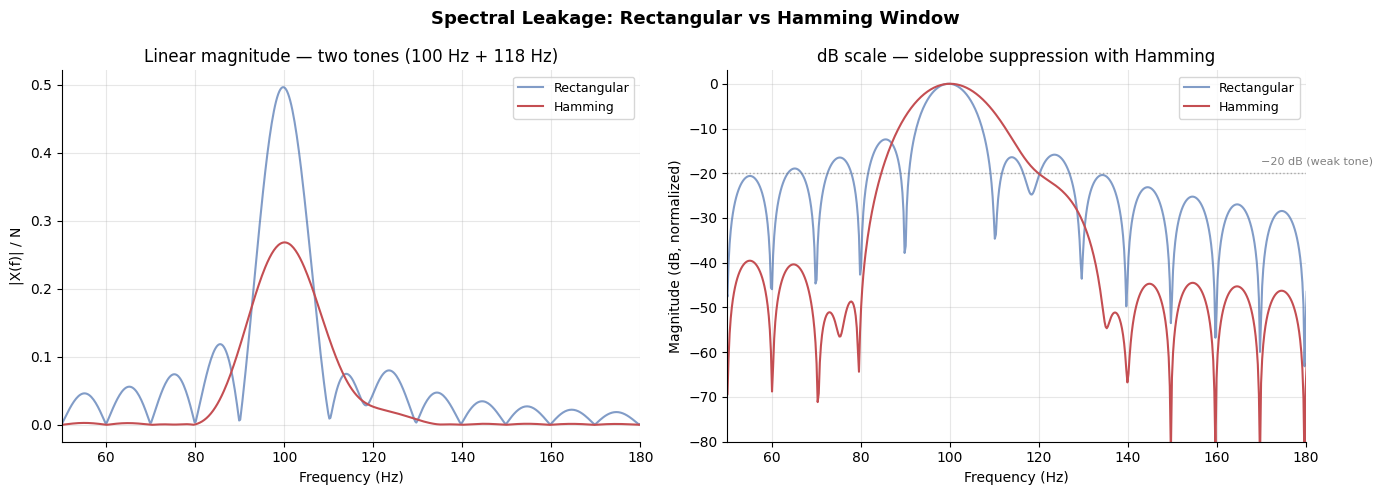

In [4]:
# Signal: strong tone at 100 Hz + weak tone at 118 Hz (20 dB below)
fs_w = 1000
T_w  = 0.1
t_w  = np.arange(0, T_w, 1/fs_w)
N_w  = len(t_w)

x_w = 1.0 * np.sin(2*np.pi*100*t_w) + 0.1 * np.sin(2*np.pi*118*t_w)

# Rectangular (no window) vs Hamming
win_rect    = np.ones(N_w)
win_hamming = np.hamming(N_w)

Nfft = 4096  # zero-pad for smoother spectral plot
f_ax = fftshift(fftfreq(Nfft, 1/fs_w))

X_rect = fftshift(fft(x_w * win_rect, n=Nfft))
X_hamm = fftshift(fft(x_w * win_hamming, n=Nfft))

# Normalize to peak
mag_rect = 20 * np.log10(np.abs(X_rect) / np.abs(X_rect).max() + 1e-12)
mag_hamm = 20 * np.log10(np.abs(X_hamm) / np.abs(X_hamm).max() + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: linear scale — see the peaks
axes[0].plot(f_ax, np.abs(X_rect)/N_w, '#4C72B0', lw=1.5, alpha=0.7, label='Rectangular')
axes[0].plot(f_ax, np.abs(X_hamm)/N_w, '#C44E52', lw=1.5, label='Hamming')
axes[0].set_xlim(50, 180)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('|X(f)| / N')
axes[0].set_title('Linear magnitude — two tones (100 Hz + 118 Hz)')
axes[0].legend(fontsize=9)

# Right: dB scale — see the sidelobes
axes[1].plot(f_ax, mag_rect, '#4C72B0', lw=1.5, alpha=0.7, label='Rectangular')
axes[1].plot(f_ax, mag_hamm, '#C44E52', lw=1.5, label='Hamming')
axes[1].set_xlim(50, 180)
axes[1].set_ylim(-80, 3)
axes[1].axhline(-20, color='gray', ls=':', lw=1, alpha=0.6)
axes[1].text(170, -18, '−20 dB (weak tone)', fontsize=8, color='gray')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude (dB, normalized)')
axes[1].set_title('dB scale — sidelobe suppression with Hamming')
axes[1].legend(fontsize=9)

fig.suptitle('Spectral Leakage: Rectangular vs Hamming Window', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
plt.close('all')

---
## Frequency Shifting: Carrier x Phasor (RF -> IF)

$$y(t) = x(t) \cdot e^{-j2\pi f_{\text{LO}} t} \quad\Longrightarrow\quad Y(f) = X(f + f_{\text{LO}})$$

Superheterodyne receiver: RF at $f_c$ enters mixer, LO provides $e^{-j2\pi f_{\text{LO}} t}$, output sits at $f_{\text{IF}} = f_c - f_{\text{LO}}$. Drag slider to change LO and watch IF shift.

In [5]:
# Unified interactive frequency shifting: RF -> IF via complex phasor
fs_rf  = 500e6
T_rf   = 5e-6
t_rf   = np.arange(0, T_rf, 1/fs_rf)
N_rf   = len(t_rf)
t_us   = t_rf * 1e6

f_carrier = 100e6
x_rf = np.cos(2*np.pi*f_carrier*t_rf) + 0.3*np.cos(2*np.pi*(f_carrier + 2e6)*t_rf)

f_ax_rf = fftshift(fftfreq(N_rf, 1/fs_rf)) / 1e6
X_rf = fftshift(fft(x_rf)) / N_rf

out_lo = widgets.Output()
lo_slider = widgets.FloatSlider(
    value=90, min=0, max=200, step=1,
    description='f_LO (MHz):', style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%'),
)

def update_lo(change):
    f_lo = change['new'] * 1e6
    phasor = np.exp(-1j * 2 * np.pi * f_lo * t_rf)
    x_if = x_rf * phasor
    X_if = fftshift(fft(x_if)) / N_rf
    f_if = f_carrier/1e6 - change['new']

    with out_lo:
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))

        axes[0, 0].plot(t_us[:200], x_rf[:200], '#4C72B0', lw=1)
        axes[0, 0].set_title(f'RF signal (carrier = {f_carrier/1e6:.0f} MHz)')
        axes[0, 0].set_xlabel('Time (us)')
        axes[0, 0].set_ylabel('Amplitude')

        axes[0, 1].plot(t_us[:200], x_if.real[:200], '#C44E52', lw=1)
        axes[0, 1].set_title(f'After mixing (real) - IF = {f_if:.0f} MHz')
        axes[0, 1].set_xlabel('Time (us)')
        axes[0, 1].set_ylabel('Amplitude')

        axes[1, 0].plot(f_ax_rf, np.abs(X_rf), '#4C72B0', lw=1.5)
        axes[1, 0].set_xlim(-200, 200)
        axes[1, 0].set_title('RF spectrum')
        axes[1, 0].set_xlabel('Frequency (MHz)')
        axes[1, 0].set_ylabel('|X(f)|')
        axes[1, 0].axvline(f_carrier/1e6, color='gray', ls=':', alpha=0.5)

        axes[1, 1].plot(f_ax_rf, np.abs(X_rf), '#4C72B0', lw=1, alpha=0.3, label='RF')
        axes[1, 1].plot(f_ax_rf, np.abs(X_if), '#C44E52', lw=1.5, label='After mixing')
        axes[1, 1].set_xlim(-200, 200)
        axes[1, 1].axvline(f_if, color='#55A868', ls='--', lw=1.5, alpha=0.8,
                           label=f'IF = {f_if:.0f} MHz')
        axes[1, 1].axvline(0, color='k', lw=0.5, ls='--', alpha=0.3)
        axes[1, 1].set_title(f'IF spectrum - shifted by -{change["new"]:.0f} MHz')
        axes[1, 1].set_xlabel('Frequency (MHz)')
        axes[1, 1].set_ylabel('|Y(f)|')
        axes[1, 1].legend(fontsize=9)

        fig.suptitle(
            f'Frequency Shifting: y(t) = x(t) * exp(-j2pi*f_LO*t)\n'
            f'f_carrier = {f_carrier/1e6:.0f} MHz,  f_LO = {change["new"]:.0f} MHz,  '
            f'f_IF = {f_carrier/1e6:.0f} - {change["new"]:.0f} = {f_if:.0f} MHz',
            fontweight='bold', fontsize=12)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

lo_slider.observe(update_lo, names='value')
display(lo_slider, out_lo)
lo_slider.value = 90

FloatSlider(value=90.0, description='f_LO (MHz):', layout=Layout(width='60%'), max=200.0, step=1.0, style=Slid…

Output()

---
## Resampling — Interactive Nyquist Explorer

Changing sample rate requires an **anti-alias filter** + **interpolation/decimation**.

$$f_{s,\text{new}} > 2\,f_{\max} \quad\text{(Nyquist condition)}$$

Drag the slider to set the new sample rate. Watch aliasing appear when $f_{s,\text{new}}/2 < f_{\max}$.

In [ ]:
# Interactive resampling with aliasing detection
out_rs = widgets.Output()

fs_orig_rs = 1000
T_rs = 0.2
t_orig_rs = np.arange(0, T_rs, 1/fs_orig_rs)
x_orig_rs = np.sin(2*np.pi*80*t_orig_rs) + 0.5*np.sin(2*np.pi*200*t_orig_rs)

fs_new_slider = widgets.IntSlider(
    value=500, min=50, max=2000, step=10,
    description='fs_new (Hz):', style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%'),
)

def update_resample(change):
    fs_new = change['new']
    num_new = max(int(len(x_orig_rs) * fs_new / fs_orig_rs), 1)
    x_rs = sig.resample(x_orig_rs, num_new)
    t_rs_new = np.arange(num_new) / fs_new

    nyquist_new = fs_new / 2
    aliasing = nyquist_new < 200
    nfft_rs = 4096

    with out_rs:
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))

        axes[0, 0].plot(t_orig_rs*1e3, x_orig_rs, '#4C72B0', lw=1.2)
        axes[0, 0].set_title(f'Original  (fs = {fs_orig_rs} Hz)')
        axes[0, 0].set_xlabel('Time (ms)')
        axes[0, 0].set_ylabel('Amplitude')

        color_rs = '#d62728' if aliasing else '#2ca02c'
        axes[0, 1].plot(t_orig_rs*1e3, x_orig_rs, '#4C72B0', lw=1, alpha=0.3)
        axes[0, 1].plot(t_rs_new*1e3, x_rs, color_rs, lw=1.5, marker='.', ms=3)
        status = "ALIASING" if aliasing else "OK"
        axes[0, 1].set_title(f'Resampled -> {fs_new} Hz  ({status})', color=color_rs)
        axes[0, 1].set_xlabel('Time (ms)')
        axes[0, 1].set_ylabel('Amplitude')

        def _spec(x, fs, nfft):
            f = fftshift(fftfreq(nfft, 1/fs))
            X = fftshift(fft(x, n=nfft)) / len(x)
            return f, np.abs(X)

        f_o, mag_o = _spec(x_orig_rs, fs_orig_rs, nfft_rs)
        f_r, mag_r = _spec(x_rs, fs_new, nfft_rs)

        axes[1, 0].plot(f_o, mag_o, '#4C72B0', lw=1.5)
        axes[1, 0].set_xlim(-fs_orig_rs/2, fs_orig_rs/2)
        axes[1, 0].set_title(f'Original spectrum (fs = {fs_orig_rs} Hz)')
        axes[1, 0].set_xlabel('Frequency (Hz)')
        axes[1, 0].set_ylabel('|X(f)|')

        axes[1, 1].plot(f_o, mag_o, '#4C72B0', lw=1, alpha=0.3, label='Original')
        axes[1, 1].plot(f_r, mag_r, color_rs, lw=1.5, label=f'Resampled ({fs_new} Hz)')
        axes[1, 1].axvline(nyquist_new, color=color_rs, ls='--', lw=1.5, alpha=0.7,
                           label=f'Nyquist = {nyquist_new:.0f} Hz')
        axes[1, 1].axvline(-nyquist_new, color=color_rs, ls='--', lw=1.5, alpha=0.7)
        axes[1, 1].set_xlim(-fs_orig_rs/2, fs_orig_rs/2)
        axes[1, 1].set_title(f'Spectrum overlay')
        axes[1, 1].set_xlabel('Frequency (Hz)')
        axes[1, 1].set_ylabel('|X(f)|')
        axes[1, 1].legend(fontsize=8)

        fig.suptitle(
            f'Resampling: {fs_orig_rs} Hz -> {fs_new} Hz  |  '
            f'Nyquist = {nyquist_new:.0f} Hz  |  f_max = 200 Hz  |  '
            f'{"ALIASING" if aliasing else "Nyquist satisfied"}',
            fontweight='bold', fontsize=12)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

fs_new_slider.observe(update_resample, names='value')
display(fs_new_slider, out_rs)
fs_new_slider.value = 500

IntSlider(value=500, description='fs_new (Hz):', layout=Layout(width='60%'), max=2000, min=50, step=10, style=…

Output()

---
## IQ to Amplitude and Phase

A signal represented in **I/Q (In-phase / Quadrature)** form encodes both amplitude and phase:

$$x(t) = I(t) + j\,Q(t) = A(t)\,e^{j\phi(t)}$$

Extraction:

$$A(t) = \sqrt{I^2(t) + Q^2(t)} = |x(t)|$$

$$\phi(t) = \arctan\!\left(\frac{Q(t)}{I(t)}\right) = \arg\!\left(x(t)\right)$$

The **instantaneous frequency** is the time derivative of the phase:

$$f_i(t) = \frac{1}{2\pi}\frac{d\phi}{dt}$$

For a chirp signal, $f_i(t)$ is a linear ramp.

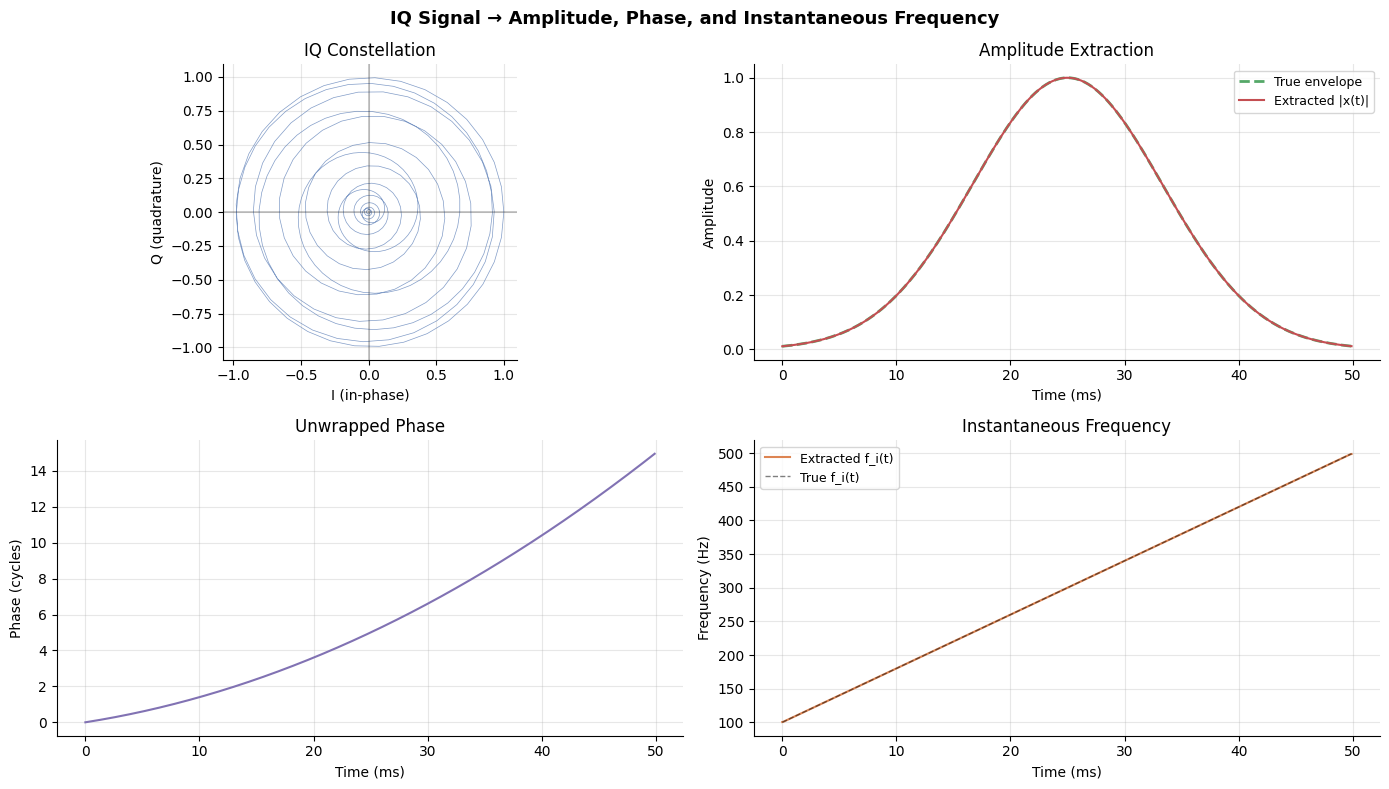

In [7]:
# Generate IQ signal: chirp with amplitude modulation
fs_iq = 10000
T_iq  = 0.05
t_iq  = np.arange(0, T_iq, 1/fs_iq)

# Instantaneous phase: chirp from 100 Hz to 500 Hz
f_start, f_end = 100, 500
mu = (f_end - f_start) / T_iq
phase_true = 2 * np.pi * (f_start * t_iq + 0.5 * mu * t_iq**2)

# Amplitude envelope: Gaussian shape
A_true = np.exp(-((t_iq - T_iq/2)**2) / (2 * (T_iq/6)**2))

# Build IQ signal
I = A_true * np.cos(phase_true)
Q = A_true * np.sin(phase_true)
x_iq = I + 1j * Q

# Extract amplitude and phase
A_extracted = np.abs(x_iq)
phi_extracted = np.unwrap(np.angle(x_iq))

# Instantaneous frequency from phase derivative
f_inst = np.gradient(phi_extracted, 1/fs_iq) / (2 * np.pi)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# IQ constellation
axes[0, 0].plot(I, Q, '#4C72B0', lw=0.5, alpha=0.7)
axes[0, 0].set_xlabel('I (in-phase)')
axes[0, 0].set_ylabel('Q (quadrature)')
axes[0, 0].set_title('IQ Constellation')
axes[0, 0].set_aspect('equal')
axes[0, 0].axhline(0, color='k', lw=0.3)
axes[0, 0].axvline(0, color='k', lw=0.3)

# Amplitude
axes[0, 1].plot(t_iq*1e3, A_true, '#55A868', lw=2, ls='--', label='True envelope')
axes[0, 1].plot(t_iq*1e3, A_extracted, '#C44E52', lw=1.5, label='Extracted |x(t)|')
axes[0, 1].set_xlabel('Time (ms)')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].set_title('Amplitude Extraction')
axes[0, 1].legend(fontsize=9)

# Phase
axes[1, 0].plot(t_iq*1e3, phi_extracted / (2*np.pi), '#8172B3', lw=1.5)
axes[1, 0].set_xlabel('Time (ms)')
axes[1, 0].set_ylabel('Phase (cycles)')
axes[1, 0].set_title('Unwrapped Phase')

# Instantaneous frequency
axes[1, 1].plot(t_iq*1e3, f_inst, '#DD8452', lw=1.5, label='Extracted f_i(t)')
f_true_inst = f_start + mu * t_iq
axes[1, 1].plot(t_iq*1e3, f_true_inst, 'k', lw=1, ls='--', alpha=0.5, label='True f_i(t)')
axes[1, 1].set_xlabel('Time (ms)')
axes[1, 1].set_ylabel('Frequency (Hz)')
axes[1, 1].set_title('Instantaneous Frequency')
axes[1, 1].legend(fontsize=9)

fig.suptitle('IQ Signal → Amplitude, Phase, and Instantaneous Frequency',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
plt.close('all')

### Interactive: IQ constellation and pulse evolution in time

Drag the slider to advance through time. Watch:
- **Left:** IQ constellation trace building up — the spiral is the chirp's increasing frequency
- **Center:** the current I/Q point highlighted on the unit circle
- **Right:** the amplitude envelope $A(t)$ with the current time marker

In [ ]:
# Interactive IQ constellation + pulse time evolution
out_iq = widgets.Output()

time_slider = widgets.FloatSlider(
    value=T_iq * 1e3, min=0.1, max=T_iq * 1e3, step=0.1,
    description='Time (ms):', style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%'),
    readout_format='.1f',
)

play_btn = widgets.Play(
    value=1, min=1, max=int(T_iq * 1e3 * 10), step=1,
    interval=50, description='Animate',
)

# Link play button to slider (play value is in 0.1 ms steps)
def sync_play(change):
    time_slider.value = change['new'] / 10.0
play_btn.observe(sync_play, names='value')

def update_iq_time(change):
    t_ms = change['new']
    t_sec = t_ms / 1e3
    idx = int(t_sec * fs_iq)
    idx = np.clip(idx, 1, len(t_iq) - 1)

    with out_iq:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        # Left: IQ constellation trace up to current time
        axes[0].plot(I[:idx], Q[:idx], '#4C72B0', lw=0.8, alpha=0.6)
        axes[0].plot(I[idx-1], Q[idx-1], 'ro', ms=8, zorder=5)
        axes[0].set_xlabel('I (in-phase)')
        axes[0].set_ylabel('Q (quadrature)')
        axes[0].set_title(f'IQ Constellation up to t = {t_ms:.1f} ms')
        axes[0].set_aspect('equal')
        lim = 1.15
        axes[0].set_xlim(-lim, lim)
        axes[0].set_ylim(-lim, lim)
        axes[0].axhline(0, color='k', lw=0.3)
        axes[0].axvline(0, color='k', lw=0.3)

        # Center: current phasor on unit circle
        theta_circle = np.linspace(0, 2*np.pi, 200)
        axes[1].plot(np.cos(theta_circle), np.sin(theta_circle), 'k-', lw=0.5, alpha=0.3)
        axes[1].arrow(0, 0, I[idx-1]*0.95, Q[idx-1]*0.95,
                      head_width=0.05, head_length=0.03, fc='#C44E52', ec='#C44E52')
        axes[1].plot(I[idx-1], Q[idx-1], 'ro', ms=8, zorder=5)
        axes[1].set_xlabel('I')
        axes[1].set_ylabel('Q')
        axes[1].set_title(f'Phasor  A={A_extracted[idx-1]:.2f}  φ={np.degrees(np.angle(x_iq[idx-1])):.0f}°')
        axes[1].set_aspect('equal')
        axes[1].set_xlim(-lim, lim)
        axes[1].set_ylim(-lim, lim)
        axes[1].axhline(0, color='k', lw=0.3)
        axes[1].axvline(0, color='k', lw=0.3)

        # Right: amplitude envelope with time marker
        axes[2].plot(t_iq*1e3, A_extracted, '#4C72B0', lw=1.5, label='|x(t)|')
        axes[2].plot(t_iq*1e3, I, '#55A868', lw=0.8, alpha=0.5, label='I(t)')
        axes[2].plot(t_iq*1e3, Q, '#DD8452', lw=0.8, alpha=0.5, label='Q(t)')
        axes[2].axvline(t_ms, color='#C44E52', lw=2, ls='--', alpha=0.8)
        axes[2].plot(t_ms, A_extracted[idx-1], 'ro', ms=8, zorder=5)
        axes[2].set_xlabel('Time (ms)')
        axes[2].set_ylabel('Amplitude')
        axes[2].set_title('Pulse Envelope + I/Q Components')
        axes[2].legend(fontsize=8, loc='upper right')

        fig.suptitle('IQ Signal Time Evolution', fontweight='bold', fontsize=13)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

time_slider.observe(update_iq_time, names='value')
display(widgets.HBox([play_btn, time_slider]), out_iq)
# Trigger initial plot
time_slider.value = T_iq * 1e3 / 2

Output()

---
## FFT-Bin IQ Extraction — Radar Pulse & Frequency Estimation vs Cramér-Rao Bound

A **radar pulse** is a gated sinusoid observed for a short window $\tau$:

$$x(t) = A \cdot \mathrm{rect}\!\left(\frac{t - \tau/2}{\tau}\right)\cos(2\pi f_c t + \phi_0) + w(t)$$

Collecting $N = \lfloor \tau f_s \rfloor$ samples, the FFT of the pulse yields an IQ phasor at each bin. The **closest bin** to $f_c$ gives the coarse IQ; **parabolic interpolation** refines the frequency estimate below the bin spacing $\Delta f = f_s / N_\text{FFT}$.

### Cramér-Rao Lower Bound (CRLB) for frequency estimation

For a real sinusoid in AWGN observed over $N$ samples at rate $f_s$ with SNR $= A^2 / (2\sigma_n^2)$, the CRLB gives the minimum achievable standard deviation of any unbiased frequency estimator (Kay 1993):

$$\sigma_f \;\geq\; \frac{f_s}{2\pi}\sqrt{\frac{6}{\mathrm{SNR} \cdot N(N^2-1)}} \;\approx\; \frac{f_s}{2\pi} \cdot \frac{\sqrt{6}}{\mathrm{SNR}^{1/2} \cdot N^{3/2}} \quad (N \gg 1)$$

Key intuitions:
| Parameter | Effect on $\sigma_f$ |
|-----------|----------------------|
| Double $N$ (longer pulse) | $\sigma_f$ drops by $2^{3/2} \approx 2.8\times$ |
| $+3$ dB SNR | $\sigma_f$ drops by $\sqrt{2} \approx 1.4\times$ |
| Double $f_s$ | $\sigma_f$ scales with $f_s$ (normalized precision is constant) |

**Use the sliders** to change pulse width, SNR, and carrier. The Monte Carlo panel shows empirical $\hat{\sigma}_f$ from repeated trials against the CRLB floor.


In [ ]:
# Pulse + correct global phase behavior

out_final = widgets.Output()

fs = 1_000_000

tau_slider = widgets.FloatSlider(value=100, min=10, max=300, step=5,
    description='τ (μs):', layout=widgets.Layout(width='40%'))

df_slider = widgets.FloatSlider(
    value=500, min=-50000, max=50000, step=500,
    description='δf (Hz):', layout=widgets.Layout(width='40%')
)

snr_slider = widgets.FloatSlider(value=25, min=0, max=40, step=1,
    description='SNR (dB):', layout=widgets.Layout(width='40%'))

phi_btn = widgets.Button(description='New φ₀')

state = {'phi0': 0.0}


def update(_=None):

    tau = tau_slider.value * 1e-6
    df  = df_slider.value
    phi0 = state['phi0']
    SNR_dB = snr_slider.value

    # TIME (global, continuous)
    T = 3 * tau
    N = int(T * fs)
    t = np.arange(N) / fs

    # Pulse window
    pulse_start = N // 3
    pulse_end   = pulse_start + int(tau * fs)

    gate = np.zeros(N)
    gate[pulse_start:pulse_end] = 1.0

    # NOISE
    A = 1.0
    SNR = 10**(SNR_dB/10)
    noise_std = A / np.sqrt(2*SNR)

    I = noise_std * np.random.randn(N)
    Q = noise_std * np.random.randn(N)

    # GLOBAL PHASE MODEL (KEY FIX)
    phi = 2*np.pi*df*t + phi0

    # Apply ONLY inside pulse
    I[pulse_start:pulse_end] += A * np.cos(phi[pulse_start:pulse_end])
    Q[pulse_start:pulse_end] += A * np.sin(phi[pulse_start:pulse_end])

    # MAG + PHASE  ← FIX HERE
    mag = np.sqrt(I**2 + Q**2)

    # Unwrap SOLO dentro il pulse — evita il random walk del rumore
    ph = np.full(N, np.nan)
    ph[pulse_start:pulse_end] = np.unwrap(
        np.arctan2(Q[pulse_start:pulse_end], I[pulse_start:pulse_end])
    )

    # Theoretical reference (invariato)
    ph_ref = np.full(N, np.nan)
    ph_ref[pulse_start:pulse_end] = phi[pulse_start:pulse_end]

    # Align theory to measured at first sample (rimuove offset φ₀ dal plot)
    offset = ph[pulse_start] - ph_ref[pulse_start]
    ph_ref += offset

    # PLOT
    with out_final:
        clear_output(wait=True)

        fig, ax = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
        t_us = t * 1e6

        ax[0].plot(t_us, I)
        ax[0].set_title("I(t)")

        ax[1].plot(t_us, Q)
        ax[1].set_title("Q(t)")

        ax[2].plot(t_us, mag)
        ax[2].set_title("Amplitude → noise / RECT / noise")

        ax[3].plot(t_us, ph, label="measured")
        ax[3].plot(t_us, ph_ref, '--', lw=2, label="theory")
        ax[3].set_title(f"Phase → linear slope = 2π·δf (δf={df:.1f} Hz)")
        ax[3].legend()

        ax[3].set_xlabel("Time (μs)")

        plt.tight_layout()
        plt.show()


def new_phi(_):
    state['phi0'] = np.random.uniform(0, 2*np.pi)
    update()


tau_slider.observe(update, 'value')
df_slider.observe(update, 'value')
snr_slider.observe(update, 'value')
phi_btn.on_click(new_phi)

display(widgets.VBox([
    tau_slider,
    df_slider,
    snr_slider,
    phi_btn,
    out_final
]))

update()

In [ ]:
# Define FFT grid
Nfft        = max(N_pulse, 4096)
delta_f_bin = fs_rp / Nfft
f_bins      = np.fft.rfftfreq(Nfft, 1 / fs_rp)

# FIXED bin selection (no noise influence)
k0          = int(round(f_c_nom / delta_f_bin))
f_bin_peak  = k0 * delta_f_bin   # this is the bin we "tune" to

# Force carrier relative to this bin
f_c_rp      = f_bin_peak + df_bin   # controlled residual
residual_f  = df_bin               # EXACT (no ambiguity)

# (Optional) still compute FFT for visualization only
X   = np.fft.rfft(x_noisy, n=Nfft)
mag = np.abs(X)


---
## Plateau Detection — Unified: Derivatives + KDE

Two complementary approaches to find **flat regions** (plateaus) in a signal:

### Approach 1: Derivatives

| Derivative | What it reveals |
|------------|-----------------|
| $A'(t) = 0$ | Flat regions (plateaus) and peaks |
| $A''(t) = 0$ | Inflection points (steepest slope) |
| $|A'(t)| < \epsilon$ | Practical plateau criterion |

**Problem:** derivatives amplify noise. Use **Savitzky-Golay** filter for robust differentiation.

### Approach 2: KDE (Kernel Density Estimation)

$$\hat{f}(x) = \frac{1}{Nh}\sum_{i=1}^{N} K\!\left(\frac{x - x_i}{h}\right)$$

A signal that spends time at a particular amplitude creates a **peak in the KDE**. Multiple plateaus -> multiple KDE peaks.

### Why unify?

- **Derivative** tells you **where** plateaus are in time (spatial localization)
- **KDE** tells you **what values** the plateaus take (amplitude identification)
- Together: detect plateau levels (KDE) then mark their time intervals (derivative threshold)

Use the sliders below to control noise, derivative threshold, and KDE bandwidth simultaneously.

In [10]:
# Unified plateau detection: Derivatives + KDE in one interactive view
from scipy.signal import savgol_filter

out_plat = widgets.Output()

noise_plat_slider = widgets.FloatSlider(
    value=0.15, min=0.0, max=0.8, step=0.02,
    description='Noise std:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='30%'),
)
deriv_thresh_slider = widgets.FloatSlider(
    value=50, min=5, max=500, step=5,
    description="|A'| threshold:", style={'description_width': 'initial'},
    layout=widgets.Layout(width='30%'),
)
bw_plat_slider = widgets.FloatSlider(
    value=0.05, min=0.005, max=0.5, step=0.005,
    description='KDE bandwidth:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='30%'),
    readout_format='.3f',
)
savgol_win_slider = widgets.IntSlider(
    value=31, min=5, max=101, step=2,
    description='Savgol window:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='30%'),
)

def update_plateau(*args):
    np.random.seed(7)
    fs_p = 10000
    T_p = 0.05
    t_p = np.arange(0, T_p, 1/fs_p)

    levels = [0.0, 1.5, 3.0, 1.5, 0.0, 3.0]

    # build exact-length plateau signal
    seg_len = int(np.ceil(len(t_p) / len(levels)))
    x_clean = np.repeat(levels, seg_len)[:len(t_p)]

    x_noisy = x_clean + noise_plat_slider.value * np.random.randn(len(t_p))
    win = min(savgol_win_slider.value, len(t_p) - 1)
    if win % 2 == 0:
        win -= 1
    win = max(win, 5)
    A_smooth = savgol_filter(x_noisy, window_length=win, polyorder=3, deriv=0, delta=1/fs_p)
    dA_smooth = savgol_filter(x_noisy, window_length=win, polyorder=3, deriv=1, delta=1/fs_p)

    thresh = deriv_thresh_slider.value
    plateau_mask = np.abs(dA_smooth) < thresh

    kde_p = gaussian_kde(x_noisy, bw_method=bw_plat_slider.value)
    amp_grid = np.linspace(x_noisy.min() - 0.5, x_noisy.max() + 0.5, 1000)
    kde_vals = kde_p(amp_grid)
    pks, _ = sig.find_peaks(kde_vals, height=0.1, distance=50)
    detected_levels = amp_grid[pks]

    with out_plat:
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 3, figsize=(16, 9))

        # (0,0) Signal + smoothed
        axes[0, 0].plot(t_p*1e3, x_noisy, '#4C72B0', lw=0.6, alpha=0.4, label='Noisy')
        axes[0, 0].plot(t_p*1e3, A_smooth, '#4C72B0', lw=2, label='Savgol')
        axes[0, 0].plot(t_p*1e3, x_clean, 'k--', lw=1, alpha=0.4, label='True')
        axes[0, 0].set_title('Signal + Savgol smoothing')
        axes[0, 0].set_xlabel('Time (ms)')
        axes[0, 0].set_ylabel('Amplitude')
        axes[0, 0].legend(fontsize=8)

        # (0,1) 1st derivative + threshold
        axes[0, 1].plot(t_p*1e3, dA_smooth, '#55A868', lw=1.5)
        axes[0, 1].axhline(thresh, color='#C44E52', ls='--', lw=1.5, alpha=0.7, label=f'+/- threshold = {thresh:.0f}')
        axes[0, 1].axhline(-thresh, color='#C44E52', ls='--', lw=1.5, alpha=0.7)
        axes[0, 1].axhline(0, color='k', lw=0.5, ls=':', alpha=0.3)
        axes[0, 1].set_title("Savgol 1st derivative A'(t)")
        axes[0, 1].set_xlabel('Time (ms)')
        axes[0, 1].set_ylabel("A'(t)")
        axes[0, 1].legend(fontsize=8)

        # (0,2) Plateau regions highlighted
        axes[0, 2].plot(t_p*1e3, x_noisy, '#4C72B0', lw=0.6, alpha=0.3)
        axes[0, 2].fill_between(t_p*1e3, x_noisy.min() - 0.3, x_noisy.max() + 0.3,
                                where=plateau_mask, alpha=0.2, color='#55A868', label='Plateau region')
        axes[0, 2].plot(t_p*1e3, A_smooth, '#4C72B0', lw=1.5)
        for lv in detected_levels:
            axes[0, 2].axhline(lv, color='#C44E52', ls=':', lw=1.5, alpha=0.7)
        axes[0, 2].set_title('Plateau regions (derivative) + levels (KDE)')
        axes[0, 2].set_xlabel('Time (ms)')
        axes[0, 2].set_ylabel('Amplitude')
        axes[0, 2].legend(fontsize=8)

        # (1,0) KDE
        axes[1, 0].fill_between(amp_grid, kde_vals, alpha=0.25, color='#4C72B0')
        axes[1, 0].plot(amp_grid, kde_vals, '#4C72B0', lw=2)
        for lv in sorted(set(levels)):
            axes[1, 0].axvline(lv, color='gray', ls=':', lw=1, alpha=0.5)
        if len(pks):
            axes[1, 0].plot(amp_grid[pks], kde_vals[pks], 'r^', ms=10, zorder=5)
            for pk in pks:
                axes[1, 0].axvline(amp_grid[pk], color='#C44E52', ls='--', lw=1.5, alpha=0.7)
        axes[1, 0].set_xlabel('Amplitude')
        axes[1, 0].set_ylabel('Density')
        axes[1, 0].set_title(f'KDE (h={bw_plat_slider.value:.3f}) - {len(pks)} plateau(s)')

        # (1,1) Histogram of plateau-region amplitudes
        plateau_amps = A_smooth[plateau_mask]
        if len(plateau_amps) > 0:
            axes[1, 1].hist(plateau_amps, bins=50, color='#55A868', alpha=0.7, edgecolor='white')
            for lv in detected_levels:
                axes[1, 1].axvline(lv, color='#C44E52', ls='--', lw=2)
        axes[1, 1].set_xlabel('Amplitude')
        axes[1, 1].set_ylabel('Count')
        axes[1, 1].set_title('Histogram of smoothed values in plateau regions')

        # (1,2) Summary
        axes[1, 2].axis('off')
        summary = (
            f"Parameters:\n"
            f"  Noise std = {noise_plat_slider.value:.2f}\n"
            f"  Savgol window = {win}\n"
            f"  Derivative threshold = {thresh:.0f}\n"
            f"  KDE bandwidth = {bw_plat_slider.value:.3f}\n\n"
            f"Results:\n"
            f"  True levels: {sorted(set(levels))}\n"
            f"  KDE-detected: [{', '.join(f'{l:.2f}' for l in sorted(detected_levels))}]\n"
            f"  Plateau fraction: {plateau_mask.mean()*100:.1f}% of samples\n\n"
            f"How they complement each other:\n"
            f"  KDE -> WHAT values (peak positions)\n"
            f"  Derivative -> WHERE in time (|A'| < eps)\n"
            f"  Together: identify + localize plateaus"
        )
        axes[1, 2].text(0.05, 0.95, summary, transform=axes[1, 2].transAxes,
                       fontsize=10, verticalalignment='top', fontfamily='monospace',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        fig.suptitle('Unified Plateau Detection: Derivatives + KDE',
                     fontweight='bold', fontsize=13)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

for w in [noise_plat_slider, deriv_thresh_slider, bw_plat_slider, savgol_win_slider]:
    w.observe(update_plateau, names='value')

display(widgets.VBox([
    widgets.HBox([noise_plat_slider, deriv_thresh_slider]),
    widgets.HBox([bw_plat_slider, savgol_win_slider]),
    out_plat,
]))
update_plateau()